# NB3: Cross-Species Convergence

**FunPan Aspergillus Pangenome Project**

Pipeline steps:

1. Map per-species orthogroups into the combined four-species pangenome
2. Convergence of the per-species significant sets, per layer and species pair
3. Directional convergence across orthogroups tested in both species
4. Permutation null model for the overlap of significant sets
5. CAZy, protease and secretome comparisons across species
6. Functional convergence of enriched annotation terms, with a permutation null

Inputs are read from `NB0_Results/` (phenotype table), `NB1_Results/` (orthogroup
annotations), `NB2_Results/` (association and enrichment results) and the combined
OrthoFinder run. Outputs are saved under `NB3_Results/`.

Analysis functions live in `funpan_utils.py` and `funpan_convergence.py`. Sections 2
to 8 each open with a bootstrap cell that sets the paths, imports those modules and
reloads that section's inputs, so any section can be run on its own from a fresh
kernel. Edit the path block at the top of a bootstrap cell to point the notebook at
your own directories.

Set `FORCE = True` in any bootstrap cell to ignore cached tables and recompute from
source.

---
## Section 1: Configuration

- Paths, species list and the FDR threshold
- `FORCE` controls whether cached tables are reused or recomputed
- Reports which inputs are present and creates the output directories before anything runs

In [1]:
import os, sys, warnings
from pathlib import Path

# --- Paths: edit these to point at your own data ---
FUNPAN_ROOT  = next(p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / 'Analysis').is_dir() and (p / 'Code').is_dir())
ANALYSIS_DIR = FUNPAN_ROOT / 'Analysis'
SPECIES_DIR  = FUNPAN_ROOT / 'Species'
GENUS        = 'Aspergillus'

SPECIES_ROOT = SPECIES_DIR / GENUS
NB0_RESULTS  = ANALYSIS_DIR / 'NB0_Results'
NB1_RESULTS  = ANALYSIS_DIR / 'NB1_Results'
NB2_RESULTS  = ANALYSIS_DIR / 'NB2_Results'
NB3_RESULTS  = ANALYSIS_DIR / 'NB3_Results'

# Combined four-species OrthoFinder run
COMBINED_OF_DIR       = SPECIES_ROOT / 'all_combined' / 'orthofinder_output' / 'Results_Apr08'
COMBINED_OG_GENECOUNT = COMBINED_OF_DIR / 'Orthogroups' / 'Orthogroups.GeneCount.tsv'
COMBINED_OG_TSV       = COMBINED_OF_DIR / 'Orthogroups' / 'Orthogroups.tsv'

# True recomputes from source and ignores every cached table
FORCE = False

sys.path.insert(0, str(ANALYSIS_DIR))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import funpan_utils as fpu
import funpan_convergence as fpc

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

SPECIES_LIST  = fpu.SPECIES_LIST
FDR_THRESHOLD = 0.1

# Reports which inputs exist and creates the output directories.
# Nothing is computed or written beyond those directories.
status = fpc.nb3_preflight(SPECIES_LIST, SPECIES_ROOT, NB0_RESULTS, NB1_RESULTS,
                           NB2_RESULTS, NB3_RESULTS, COMBINED_OF_DIR)

NB3 inputs
  combined OrthoFinder run: found
  -> /datadrive/Species/Aspergillus/all_combined/orthofinder_output/Results_Apr08/Orthogroups/Orthogroups.tsv
  NB0 phenotype table: found

          og_consensus orthofinder gwas_results enrichment
species                                                   
fumigatus           ok          ok           ok         ok
flavus              ok          ok           ok         ok
niger               ok          ok           ok         ok
oryzae              ok          ok      MISSING    MISSING

2 missing per-species input(s); run NB1 and NB2 first.


### 1.1 Combined OrthoFinder run

- Gene-count matrix and long per-protein table for the four-species run
- Genomes excluded by ANI or contamination QC are dropped after loading

In [2]:
combined_genecount, combined_og_long, genome_mapping = fpc.load_combined_orthofinder(
    COMBINED_OG_GENECOUNT, COMBINED_OG_TSV, SPECIES_LIST
)

Loading combined OrthoFinder gene count matrix...
  Gene count matrix: (15163, 212)

Loading combined OrthoFinder long format...
  Long format: (2328114, 4)
  Unique orthogroups: 15163
  Unique species: 4
  Dropped 1 excluded genome column(s): ['fumigatus__GCA_049901915.1']

Genome-species mapping: 210 genomes
  fumigatus: 88 genomes
  flavus: 70 genomes
  niger: 19 genomes
  oryzae: 33 genomes


### 1.2 Phenotype labels

- Phenotype table from NB0, one row per genome

In [3]:
pheno_classified = pd.read_csv(NB0_RESULTS / 'phenotype_classified_for_gwas.csv')
print(f'Phenotype classification table: {pheno_classified.shape}')
display(pheno_classified.head())

Phenotype classification table: (206, 69)


,Assembly Accession,Assembly Name,Organism Name,Organism Taxonomic ID,ANI Check status,Organism Infraspecific Names Breed,Organism Infraspecific Names Strain,Organism Infraspecific Names Cultivar,Organism Infraspecific Names Ecotype,Organism Infraspecific Names Isolate,...,PhenotypeScores,PhenotypeMatched,FieldProvenance,NegationsApplied,IsolationClass,IsolationSubclass,IsolationSubtype,ClassConfidence,ClassificationConfidence,UsageClass
0,GCA_000150145.1,ASM15014v1,Aspergillus fumigatus A1163,451804,NaN,NaN,A1163,NaN,NaN,NaN,...,"{""Human-pathogenic"": 10.0, ""Animal-pathogenic""...","{""Human-pathogenic"": [""Established strain: Asp...","{""Provenance:Clinical"": [""description"", ""comme...",[],Human,Human-pathogenic,Human-pathogenic,high,high,Pathogenic
1,GCA_001599455.1,JCM_10253_assembly_v001,Aspergillus fumigatus var. fumigatus,41122,NaN,NaN,JCM 10253,NaN,NaN,NaN,...,"{""Human-pathogenic"": 0.0, ""Animal-pathogenic"":...","{""Environmental"": [""Inferred from Environmenta...","{""Provenance:Environmental"": [""description"", ""...",[],Environmental,Environmental,Environmental,low,low,Wild-type
2,GCA_001715275.2,ASM171527v2,Aspergillus fumigatus,746128,NaN,NaN,LMB-35Aa,NaN,NaN,NaN,...,"{""Human-pathogenic"": 0.0, ""Animal-pathogenic"":...","{""Environmental"": [""Inferred from Environmenta...","{""Provenance:Environmental"": [""isolation_sourc...",[],Environmental,Environmental,Environmental,low,low,Wild-type
3,GCA_015572005.1,ASM1557200v1,Aspergillus fumigatus,746128,NaN,NaN,CAPA A,NaN,NaN,NaN,...,"{""Human-pathogenic"": 9.0, ""Animal-pathogenic"":...","{""Human-pathogenic"": [""aspergillosis"", ""CAPA"",...","{""Provenance:Clinical"": [""isolation_source"", ""...",[],Human,Human-pathogenic,Human-pathogenic,high,high,Pathogenic
4,GCA_015572015.1,ASM1557201v1,Aspergillus fumigatus,746128,NaN,NaN,CAPA B,NaN,NaN,NaN,...,"{""Human-pathogenic"": 9.0, ""Animal-pathogenic"":...","{""Human-pathogenic"": [""aspergillosis"", ""CAPA"",...","{""Provenance:Clinical"": [""isolation_source"", ""...",[],Human,Human-pathogenic,Human-pathogenic,high,high,Pathogenic


### 1.3 Per-species association results

- Association tables from NB2, per species, contrast and feature layer

In [4]:
species_gwas = fpc.load_gwas_results_from_nb2(SPECIES_LIST, NB2_RESULTS)

fumigatus: loaded 14 result files
  bgc_pav_assoc_environmental_vs_rest: 0 features, 0 significant
  bgc_pav_assoc_human_pathogenic_vs_rest: 0 features, 0 significant
  cnv_assoc_environmental_vs_rest: 1873 features, 88 significant
  cnv_assoc_human_pathogenic_vs_rest: 1873 features, 88 significant
  gcf_cnv_assoc_environmental_vs_rest: 34 features, 3 significant
  gcf_cnv_assoc_environmental_vs_rest_annotated: 34 features, 3 significant
  gcf_cnv_assoc_human_pathogenic_vs_rest: 34 features, 3 significant
  gcf_cnv_assoc_human_pathogenic_vs_rest_annotated: 34 features, 3 significant
  gcf_pav_assoc_environmental_vs_rest: 34 features, 3 significant
  gcf_pav_assoc_environmental_vs_rest_annotated: 34 features, 3 significant
  gcf_pav_assoc_human_pathogenic_vs_rest: 34 features, 3 significant
  gcf_pav_assoc_human_pathogenic_vs_rest_annotated: 34 features, 3 significant
  pav_assoc_environmental_vs_rest: 1873 features, 92 significant
  pav_assoc_human_pathogenic_vs_rest: 1873 features, 92

---
## Section 2: Species to Genus Orthogroup Mapping

- `build_species_to_combined_og_map()` links each per-species orthogroup to the combined-run orthogroups that share its proteins
- Proteins are keyed by assembly accession and protein ID together, since locus tags repeat across genomes
- One species orthogroup can map to several genus orthogroups and vice versa
- Requires Section 1.1

In [5]:
# Standalone bootstrap: run this cell to use Section 2 from a fresh kernel.
import os, sys, warnings
from pathlib import Path

# --- Paths: edit these to point at your own data ---
FUNPAN_ROOT  = next(p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / 'Analysis').is_dir() and (p / 'Code').is_dir())
ANALYSIS_DIR = FUNPAN_ROOT / 'Analysis'
SPECIES_DIR  = FUNPAN_ROOT / 'Species'
GENUS        = 'Aspergillus'

SPECIES_ROOT = SPECIES_DIR / GENUS
NB0_RESULTS  = ANALYSIS_DIR / 'NB0_Results'
NB1_RESULTS  = ANALYSIS_DIR / 'NB1_Results'
NB2_RESULTS  = ANALYSIS_DIR / 'NB2_Results'
NB3_RESULTS  = ANALYSIS_DIR / 'NB3_Results'

# Combined four-species OrthoFinder run
COMBINED_OF_DIR       = SPECIES_ROOT / 'all_combined' / 'orthofinder_output' / 'Results_Apr08'
COMBINED_OG_GENECOUNT = COMBINED_OF_DIR / 'Orthogroups' / 'Orthogroups.GeneCount.tsv'
COMBINED_OG_TSV       = COMBINED_OF_DIR / 'Orthogroups' / 'Orthogroups.tsv'

# True recomputes from source and ignores every cached table
FORCE = False

sys.path.insert(0, str(ANALYSIS_DIR))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import funpan_utils as fpu
import funpan_convergence as fpc

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

SPECIES_LIST  = fpu.SPECIES_LIST
FDR_THRESHOLD = 0.1

combined_genecount, combined_og_long, genome_mapping = fpc.load_combined_orthofinder(
    COMBINED_OG_GENECOUNT, COMBINED_OG_TSV, SPECIES_LIST
)

Loading combined OrthoFinder gene count matrix...
  Gene count matrix: (15163, 212)

Loading combined OrthoFinder long format...
  Long format: (2328114, 4)
  Unique orthogroups: 15163
  Unique species: 4
  Dropped 1 excluded genome column(s): ['fumigatus__GCA_049901915.1']

Genome-species mapping: 210 genomes
  fumigatus: 88 genomes
  flavus: 70 genomes
  niger: 19 genomes
  oryzae: 33 genomes


In [6]:
species_og_to_combined, SPECIES_OG_PATHS = fpc.build_species_to_combined_og_map(
    SPECIES_LIST, SPECIES_ROOT, combined_og_long
)

  fumigatus: using /datadrive/Species/Aspergillus/fumigatus/orthofinder_output/Results_Dec11/Orthogroups/Orthogroups.tsv
  flavus: using /datadrive/Species/Aspergillus/flavus/orthofinder_output/Results_Dec13/Orthogroups/Orthogroups.tsv
  niger: using /datadrive/Species/Aspergillus/niger/orthofinder_output/Results_Apr08/Orthogroups/Orthogroups.tsv
  oryzae: using /datadrive/Species/Aspergillus/oryzae/orthofinder_output/Results_Dec10/Orthogroups/Orthogroups.tsv
Protein-to-combined-OG lookup: 2318167 proteins

fumigatus: loading species OrthoFinder from /datadrive/Species/Aspergillus/fumigatus/orthofinder_output/Results_Dec11/Orthogroups/Orthogroups.tsv
  10881 species OGs mapped to combined OGs (827229 protein links)
    combined OGs per species OG: median 1, mean 1.02, max 6

flavus: loading species OrthoFinder from /datadrive/Species/Aspergillus/flavus/orthofinder_output/Results_Dec13/Orthogroups/Orthogroups.tsv
  14438 species OGs mapped to combined OGs (862307 protein links)
    comb

---
## Section 3: Convergence of Significant Orthogroups

- Projects each species' significant orthogroups into genus coordinates and intersects the two sets
- Requires Sections 1.3 and 2

In [7]:
# Standalone bootstrap: run this cell to use Section 3 from a fresh kernel.
import os, sys, warnings
from pathlib import Path

# --- Paths: edit these to point at your own data ---
FUNPAN_ROOT  = next(p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / 'Analysis').is_dir() and (p / 'Code').is_dir())
ANALYSIS_DIR = FUNPAN_ROOT / 'Analysis'
SPECIES_DIR  = FUNPAN_ROOT / 'Species'
GENUS        = 'Aspergillus'

SPECIES_ROOT = SPECIES_DIR / GENUS
NB0_RESULTS  = ANALYSIS_DIR / 'NB0_Results'
NB1_RESULTS  = ANALYSIS_DIR / 'NB1_Results'
NB2_RESULTS  = ANALYSIS_DIR / 'NB2_Results'
NB3_RESULTS  = ANALYSIS_DIR / 'NB3_Results'

# Combined four-species OrthoFinder run
COMBINED_OF_DIR       = SPECIES_ROOT / 'all_combined' / 'orthofinder_output' / 'Results_Apr08'
COMBINED_OG_GENECOUNT = COMBINED_OF_DIR / 'Orthogroups' / 'Orthogroups.GeneCount.tsv'
COMBINED_OG_TSV       = COMBINED_OF_DIR / 'Orthogroups' / 'Orthogroups.tsv'

# True recomputes from source and ignores every cached table
FORCE = False

sys.path.insert(0, str(ANALYSIS_DIR))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import funpan_utils as fpu
import funpan_convergence as fpc

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

SPECIES_LIST  = fpu.SPECIES_LIST
FDR_THRESHOLD = 0.1

combined_genecount, combined_og_long, genome_mapping = fpc.load_combined_orthofinder(
    COMBINED_OG_GENECOUNT, COMBINED_OG_TSV, SPECIES_LIST
)
species_gwas = fpc.load_gwas_results_from_nb2(SPECIES_LIST, NB2_RESULTS)
species_og_to_combined, SPECIES_OG_PATHS = fpc.build_species_to_combined_og_map(
    SPECIES_LIST, SPECIES_ROOT, combined_og_long
)

Loading combined OrthoFinder gene count matrix...
  Gene count matrix: (15163, 212)

Loading combined OrthoFinder long format...
  Long format: (2328114, 4)
  Unique orthogroups: 15163
  Unique species: 4
  Dropped 1 excluded genome column(s): ['fumigatus__GCA_049901915.1']

Genome-species mapping: 210 genomes
  fumigatus: 88 genomes
  flavus: 70 genomes
  niger: 19 genomes
  oryzae: 33 genomes
fumigatus: loaded 14 result files
  bgc_pav_assoc_environmental_vs_rest: 0 features, 0 significant
  bgc_pav_assoc_human_pathogenic_vs_rest: 0 features, 0 significant
  cnv_assoc_environmental_vs_rest: 1873 features, 88 significant
  cnv_assoc_human_pathogenic_vs_rest: 1873 features, 88 significant
  gcf_cnv_assoc_environmental_vs_rest: 34 features, 3 significant
  gcf_cnv_assoc_environmental_vs_rest_annotated: 34 features, 3 significant
  gcf_cnv_assoc_human_pathogenic_vs_rest: 34 features, 3 significant
  gcf_cnv_assoc_human_pathogenic_vs_rest_annotated: 34 features, 3 significant
  gcf_pav_as

### 3.1 Pathogenic contrast, A. fumigatus against A. flavus

In [8]:
mapped_pav = fpc.transfer_gwas_hits_to_combined(
    species_gwas, species_og_to_combined, layer_pattern='pav_assoc')
mapped_cnv = fpc.transfer_gwas_hits_to_combined(
    species_gwas, species_og_to_combined, layer_pattern='cnv_assoc')

print('=' * 70)
print('PATHOGENIC CONVERGENCE: A. fumigatus vs A. flavus')
print('=' * 70)
path_pav_conv = fpc.find_convergent_hits('fumigatus', 'flavus', mapped_pav,
    contrast_pattern='human_pathogenic_vs_rest', fdr_thresh=FDR_THRESHOLD)
path_cnv_conv = fpc.find_convergent_hits('fumigatus', 'flavus', mapped_cnv,
    contrast_pattern='human_pathogenic_vs_rest', fdr_thresh=FDR_THRESHOLD)

path_convergent = pd.concat([path_pav_conv, path_cnv_conv], ignore_index=True) \
    if len(path_pav_conv) + len(path_cnv_conv) > 0 else pd.DataFrame()

print(f'\nPAV convergent orthogroups: {len(path_pav_conv)}')
print(f'CNV convergent orthogroups: {len(path_cnv_conv)}')

path_meta = pd.DataFrame()
path_robust = pd.DataFrame()

if not path_pav_conv.empty:
    path_pav_conv.to_csv(NB3_RESULTS / 'convergence' / 'pathogenic_functional_pav_convergence.csv',
                          index=False)
if not path_cnv_conv.empty:
    path_cnv_conv.to_csv(NB3_RESULTS / 'convergence' / 'pathogenic_functional_cnv_convergence.csv',
                          index=False)

report = fpc.generate_cross_species_report(
    path_convergent if not path_convergent.empty else pd.DataFrame(),
    path_meta if not path_meta.empty else pd.DataFrame(),
    path_robust if not path_robust.empty else pd.DataFrame(),
    'Pathogenic (fumigatus vs flavus)'
)
print(report)

  fumigatus__pav_assoc_environmental_vs_rest: 1981 mapped rows, 99 significant
  fumigatus__pav_assoc_human_pathogenic_vs_rest: 1981 mapped rows, 99 significant
  flavus__pav_assoc_environmental_vs_rest: 3163 mapped rows, 29 significant
  flavus__pav_assoc_human_pathogenic_vs_rest: 3163 mapped rows, 65 significant
  flavus__pav_assoc_plant_pathogenic_vs_rest: 3163 mapped rows, 123 significant
  niger__pav_assoc_environmental_vs_rest: 3953 mapped rows, 114 significant
  niger__pav_assoc_industrial_trait_vs_rest: 3953 mapped rows, 4 significant
  fumigatus__cnv_assoc_environmental_vs_rest: 1981 mapped rows, 90 significant
  fumigatus__cnv_assoc_human_pathogenic_vs_rest: 1981 mapped rows, 90 significant
  flavus__cnv_assoc_environmental_vs_rest: 3163 mapped rows, 28 significant
  flavus__cnv_assoc_human_pathogenic_vs_rest: 3163 mapped rows, 50 significant
  flavus__cnv_assoc_plant_pathogenic_vs_rest: 3163 mapped rows, 104 significant
  niger__cnv_assoc_environmental_vs_rest: 3953 mapped r

### 3.2 Industrial contrast, A. niger against A. oryzae

In [9]:
ind_results = fpc.test_industrial_convergence(
    species_gwas, mapped_pav, mapped_cnv,
    species_og_to_combined, fdr_threshold=FDR_THRESHOLD,
    nb3_results=NB3_RESULTS
)
ind_pav_conv = ind_results.get('ind_pav_conv', pd.DataFrame())
ind_cnv_conv = ind_results.get('ind_cnv_conv', pd.DataFrame())
print(f'\nPAV convergent orthogroups: {len(ind_pav_conv)}')
print(f'CNV convergent orthogroups: {len(ind_cnv_conv)}')

INDUSTRIAL CONVERGENCE: A. niger vs A. oryzae
  Contrast: industrial_trait_vs_rest

--- PAV OG Convergence ---
  No matching results for niger or oryzae with pattern "industrial"

--- CNV OG Convergence ---
  No matching results for niger or oryzae with pattern "industrial"

--- Functional Convergence ---
  No functional GWAS results to compare (expected: A. oryzae has 0 significant hits).

Preparing industrial species results for meta-analysis...

Identifying convergent hits (PAV level)...
  Convergent hits found: 0
CROSS-SPECIES ANALYSIS REPORT: Industrial (niger vs oryzae)

1. CONVERGENT HITS (Section 6.1)
----------------------------------------
No convergent hits identified

2. META-ANALYSIS RESULTS (Section 6.2)
----------------------------------------
No meta-analysis results available

3. ROBUSTNESS ANALYSIS (Section 6.3)
----------------------------------------
No robustness results available

4. KEY FINDINGS
----------------------------------------


PAV convergent orthogroup

### 3.3 Gene cluster families

- Resolves each significant GCF to the genus-level OGs of the genes in its member regions
- BiG-SCAPE families carry no shared identifier across per-species runs
- Reports the shared OG count per cross-species GCF pair
- Writes `gcf_orthogroup_overlap.csv`

In [10]:
gcf_fam_ogs, gcf_pairs = fpc.gcf_orthogroup_overlap(
    ['fumigatus', 'flavus'], 'human_pathogenic_vs_rest',
    SPECIES_ROOT, NB1_RESULTS, NB2_RESULTS, COMBINED_OG_TSV, NB3_RESULTS
)
gcf_pairs.drop(columns='shared_ids')

fumigatus: 3 significant GCFs -> 102 genus-level orthogroups
flavus: 1 significant GCFs -> 37 genus-level orthogroups
shared orthogroups between the two sets: 0


,fumigatus_GCF,flavus_GCF,fumigatus_n_orthogroups,flavus_n_orthogroups,shared_orthogroups
0,FAM_00050,FAM_00077,29,37,0
1,FAM_00070,FAM_00077,70,37,0
2,FAM_00074,FAM_00077,69,37,0


---
## Section 4: Directional Convergence Across Tested Orthogroups

- Keeps every genus orthogroup tested in both species and classifies each by whether the sign of beta agrees
- Reports the projection accounting, the concordance table and a merge-rule sensitivity check
- Saved to `NB3_Results/method3_*.csv` and `NB3_Results/convergence/pathogenic_method3_*_convergence.csv`
- Requires Section 2

In [11]:
# Standalone bootstrap: run this cell to use Section 4 from a fresh kernel.
import os, sys, warnings
from pathlib import Path

# --- Paths: edit these to point at your own data ---
FUNPAN_ROOT  = next(p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / 'Analysis').is_dir() and (p / 'Code').is_dir())
ANALYSIS_DIR = FUNPAN_ROOT / 'Analysis'
SPECIES_DIR  = FUNPAN_ROOT / 'Species'
GENUS        = 'Aspergillus'

SPECIES_ROOT = SPECIES_DIR / GENUS
NB0_RESULTS  = ANALYSIS_DIR / 'NB0_Results'
NB1_RESULTS  = ANALYSIS_DIR / 'NB1_Results'
NB2_RESULTS  = ANALYSIS_DIR / 'NB2_Results'
NB3_RESULTS  = ANALYSIS_DIR / 'NB3_Results'

# Combined four-species OrthoFinder run
COMBINED_OF_DIR       = SPECIES_ROOT / 'all_combined' / 'orthofinder_output' / 'Results_Apr08'
COMBINED_OG_GENECOUNT = COMBINED_OF_DIR / 'Orthogroups' / 'Orthogroups.GeneCount.tsv'
COMBINED_OG_TSV       = COMBINED_OF_DIR / 'Orthogroups' / 'Orthogroups.tsv'

# True recomputes from source and ignores every cached table
FORCE = False

sys.path.insert(0, str(ANALYSIS_DIR))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import funpan_utils as fpu
import funpan_convergence as fpc

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

SPECIES_LIST  = fpu.SPECIES_LIST
FDR_THRESHOLD = 0.1

combined_genecount, combined_og_long, genome_mapping = fpc.load_combined_orthofinder(
    COMBINED_OG_GENECOUNT, COMBINED_OG_TSV, SPECIES_LIST
)
species_gwas = fpc.load_gwas_results_from_nb2(SPECIES_LIST, NB2_RESULTS)
species_og_to_combined, SPECIES_OG_PATHS = fpc.build_species_to_combined_og_map(
    SPECIES_LIST, SPECIES_ROOT, combined_og_long
)

Loading combined OrthoFinder gene count matrix...
  Gene count matrix: (15163, 212)

Loading combined OrthoFinder long format...
  Long format: (2328114, 4)
  Unique orthogroups: 15163
  Unique species: 4
  Dropped 1 excluded genome column(s): ['fumigatus__GCA_049901915.1']

Genome-species mapping: 210 genomes
  fumigatus: 88 genomes
  flavus: 70 genomes
  niger: 19 genomes
  oryzae: 33 genomes
fumigatus: loaded 14 result files
  bgc_pav_assoc_environmental_vs_rest: 0 features, 0 significant
  bgc_pav_assoc_human_pathogenic_vs_rest: 0 features, 0 significant
  cnv_assoc_environmental_vs_rest: 1873 features, 88 significant
  cnv_assoc_human_pathogenic_vs_rest: 1873 features, 88 significant
  gcf_cnv_assoc_environmental_vs_rest: 34 features, 3 significant
  gcf_cnv_assoc_environmental_vs_rest_annotated: 34 features, 3 significant
  gcf_cnv_assoc_human_pathogenic_vs_rest: 34 features, 3 significant
  gcf_cnv_assoc_human_pathogenic_vs_rest_annotated: 34 features, 3 significant
  gcf_pav_as

In [12]:
# --- Tweakable parameters ---
PAIR            = ['fumigatus', 'flavus']
CONTRAST        = 'human_pathogenic_vs_rest'
PANGENOME_SIZE  = {'fumigatus': 10881, 'flavus': 14450}   # orthogroups per species pangenome

method3 = fpc.method3_directional_convergence(
    species_og_to_combined, NB2_RESULTS, NB3_RESULTS,
    pair_m3=PAIR, contrast_m3=CONTRAST, pangenome_size_m3=PANGENOME_SIZE,
)
display(method3['projection'])
display(method3['concordance'])
display(method3['sensitivity'])

PAV: sig genus OGs 97 vs 65, jointly significant 0; significant but untested in the partner species: fumigatus 69, flavus 56
CNV: sig genus OGs 89 vs 50, jointly significant 0; significant but untested in the partner species: fumigatus 67, flavus 43

--- projection accounting ---
  layer    species  og_in_pangenome  og_tested  og_sig_q05  species_og_split  links_added_by_splits  total_links  genus_og_receiving_multiple  links_lost_to_merges  distinct_genus_og
0   PAV  fumigatus            10881       1873          92                89                    108         1981                          177                   326               1655
1   PAV     flavus            14450       3011          62               136                    152         3163                          356                   641               2522
2   CNV  fumigatus            10881       1873          88                89                    108         1981                          177                   326       

,layer,species,og_in_pangenome,og_tested,og_sig_q05,species_og_split,links_added_by_splits,total_links,genus_og_receiving_multiple,links_lost_to_merges,distinct_genus_og
0,PAV,fumigatus,10881,1873,92,89,108,1981,177,326,1655
1,PAV,flavus,14450,3011,62,136,152,3163,356,641,2522
2,CNV,fumigatus,10881,1873,88,89,108,1981,177,326,1655
3,CNV,flavus,14450,3011,49,136,152,3163,356,641,2522


,layer,merge_rule,n_shared_tested,n_concordant,n_discordant,pct_concordant,sign_test_p,ci_low,ci_high,spearman_rho,spearman_p,pearson_r,pearson_p,n_concordant_up,n_concordant_down,n_sig_fumigatus_only,n_sig_flavus_only,n_sig_both,n_sig_neither
0,PAV,most_significant,448,221,227,49.3,0.813288,0.446068,0.540628,-0.023128,0.625397,-0.002887,0.951405,139,82,28,9,0,411
1,CNV,most_significant,448,220,228,49.1,0.740898,0.443854,0.538407,-0.019663,0.678094,0.000604,0.989837,147,73,22,7,0,419


,layer,merge_rule,n_shared_tested,n_concordant,n_discordant,pct_concordant,sign_test_p,ci_low,ci_high,spearman_rho,spearman_p,pearson_r,pearson_p
0,PAV,most_significant,448,221,227,49.3,0.813288,0.446068,0.540628,-0.023128,0.625397,-0.002887,0.951405
1,PAV,median_beta,448,225,223,50.2,0.962325,0.454934,0.549501,-0.026983,0.568923,-0.017709,0.708551
2,PAV,drop_ambiguous,278,139,139,50.0,1.000000,0.439700,0.560300,-0.003312,0.956160,-0.021595,0.719978
3,CNV,most_significant,448,220,228,49.1,0.740898,0.443854,0.538407,-0.019663,0.678094,0.000604,0.989837
4,CNV,median_beta,448,225,223,50.2,0.962325,0.454934,0.549501,0.001397,0.976484,0.001099,0.981501
5,CNV,drop_ambiguous,278,136,142,48.9,0.764331,0.429038,0.549611,0.007704,0.898249,-0.012799,0.831761


### 4.1 Directional convergence figure

- Concordant up, concordant down and discordant shares of the tested orthogroups, per layer
- Saved to `NB3_Results/convergence_summary_combined.png`

Saved: /datadrive/Analysis/NB3_Results/convergence_summary_combined.png


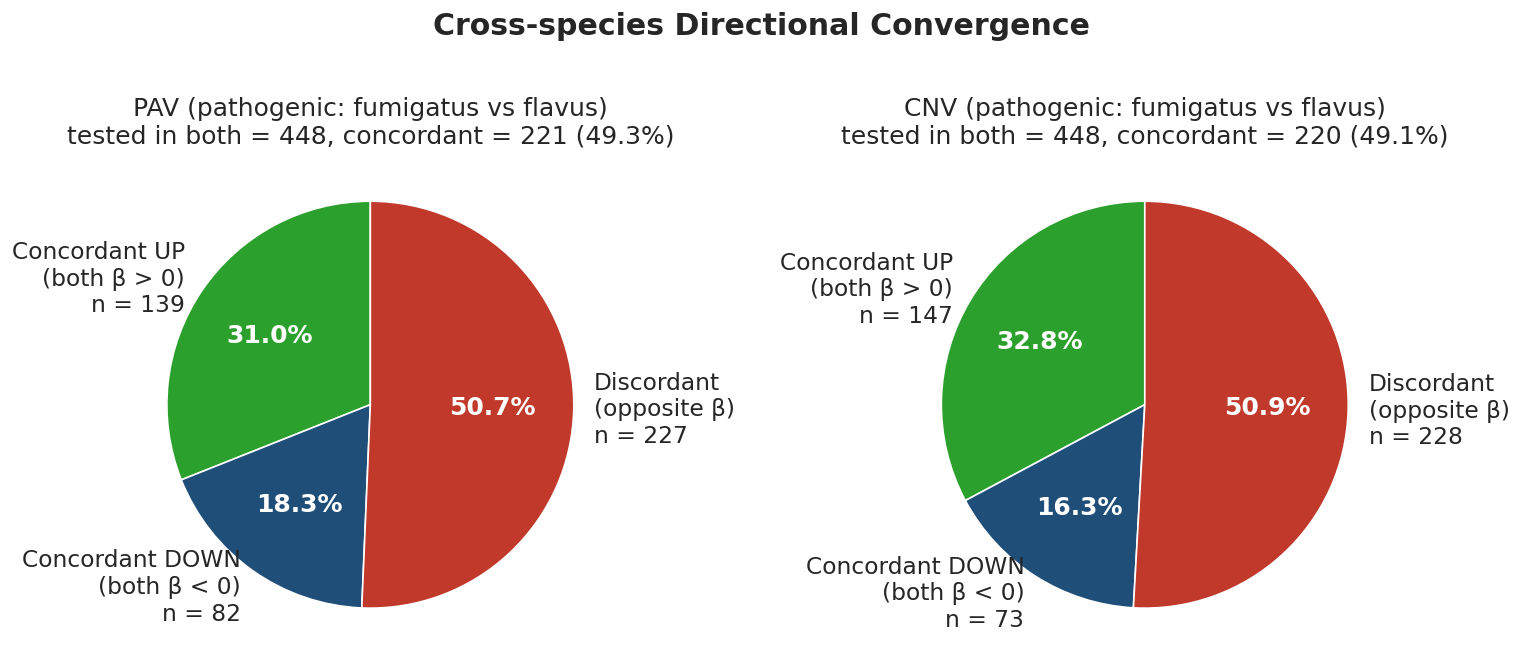

In [13]:
# --- Tweakable parameters ---
FONTSIZE = 15
DPI      = 400
FIG_W_PER_PIE = 6.5
FIG_H         = 5.6

fig_pies = fpc.plot_convergence_pies(
    NB3_RESULTS, fs_cs=FONTSIZE, dpi_cs=DPI,
    fig_w_per_pie_cs=FIG_W_PER_PIE, fig_h_cs=FIG_H,
)
plt.show()

---
## Section 5: Permutation Null Model

- Draws random orthogroup sets of the observed sizes and records how often they overlap at least as much as the real sets
- Saved to `NB3_Results/permutation_null_model.csv`
- Requires Section 3

In [14]:
# Standalone bootstrap: run this cell to use Section 5 from a fresh kernel.
import os, sys, warnings
from pathlib import Path

# --- Paths: edit these to point at your own data ---
FUNPAN_ROOT  = next(p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / 'Analysis').is_dir() and (p / 'Code').is_dir())
ANALYSIS_DIR = FUNPAN_ROOT / 'Analysis'
SPECIES_DIR  = FUNPAN_ROOT / 'Species'
GENUS        = 'Aspergillus'

SPECIES_ROOT = SPECIES_DIR / GENUS
NB0_RESULTS  = ANALYSIS_DIR / 'NB0_Results'
NB1_RESULTS  = ANALYSIS_DIR / 'NB1_Results'
NB2_RESULTS  = ANALYSIS_DIR / 'NB2_Results'
NB3_RESULTS  = ANALYSIS_DIR / 'NB3_Results'

# Combined four-species OrthoFinder run
COMBINED_OF_DIR       = SPECIES_ROOT / 'all_combined' / 'orthofinder_output' / 'Results_Apr08'
COMBINED_OG_GENECOUNT = COMBINED_OF_DIR / 'Orthogroups' / 'Orthogroups.GeneCount.tsv'
COMBINED_OG_TSV       = COMBINED_OF_DIR / 'Orthogroups' / 'Orthogroups.tsv'

# True recomputes from source and ignores every cached table
FORCE = False

sys.path.insert(0, str(ANALYSIS_DIR))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import funpan_utils as fpu
import funpan_convergence as fpc

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

SPECIES_LIST  = fpu.SPECIES_LIST
FDR_THRESHOLD = 0.1

combined_genecount, combined_og_long, genome_mapping = fpc.load_combined_orthofinder(
    COMBINED_OG_GENECOUNT, COMBINED_OG_TSV, SPECIES_LIST
)
species_gwas = fpc.load_gwas_results_from_nb2(SPECIES_LIST, NB2_RESULTS)
species_og_to_combined, SPECIES_OG_PATHS = fpc.build_species_to_combined_og_map(
    SPECIES_LIST, SPECIES_ROOT, combined_og_long
)
mapped_pav = fpc.transfer_gwas_hits_to_combined(
    species_gwas, species_og_to_combined, layer_pattern='pav_assoc')
mapped_cnv = fpc.transfer_gwas_hits_to_combined(
    species_gwas, species_og_to_combined, layer_pattern='cnv_assoc')


Loading combined OrthoFinder gene count matrix...
  Gene count matrix: (15163, 212)

Loading combined OrthoFinder long format...
  Long format: (2328114, 4)
  Unique orthogroups: 15163
  Unique species: 4
  Dropped 1 excluded genome column(s): ['fumigatus__GCA_049901915.1']

Genome-species mapping: 210 genomes
  fumigatus: 88 genomes
  flavus: 70 genomes
  niger: 19 genomes
  oryzae: 33 genomes
fumigatus: loaded 14 result files
  bgc_pav_assoc_environmental_vs_rest: 0 features, 0 significant
  bgc_pav_assoc_human_pathogenic_vs_rest: 0 features, 0 significant
  cnv_assoc_environmental_vs_rest: 1873 features, 88 significant
  cnv_assoc_human_pathogenic_vs_rest: 1873 features, 88 significant
  gcf_cnv_assoc_environmental_vs_rest: 34 features, 3 significant
  gcf_cnv_assoc_environmental_vs_rest_annotated: 34 features, 3 significant
  gcf_cnv_assoc_human_pathogenic_vs_rest: 34 features, 3 significant
  gcf_cnv_assoc_human_pathogenic_vs_rest_annotated: 34 features, 3 significant
  gcf_pav_as

In [15]:
# --- Tweakable parameters ---
N_PERMS = 1000

null_result = fpc.run_permutation_null(
    mapped_pav, mapped_cnv, NB3_RESULTS,
    n_perms=N_PERMS, fdr_threshold=FDR_THRESHOLD,
)
null_summary = null_result['summary']
display(null_summary)

                        contrast layer  n_sp1_sig  n_sp2_sig  observed  null_mean  null_max  null_q95  p_value  n_perms
pathogenic (fumigatus vs flavus)   PAV         98         77         0      0.849         4       2.0      1.0     1000
pathogenic (fumigatus vs flavus)   CNV         90         56         0      0.519         5       2.0      1.0     1000
    industrial (niger vs oryzae)   PAV          0          0         0      0.000         0       0.0      1.0     1000
    industrial (niger vs oryzae)   CNV          0          0         0      0.000         0       0.0      1.0     1000


,contrast,layer,n_sp1_sig,n_sp2_sig,observed,null_mean,null_max,null_q95,p_value,n_perms
0,pathogenic (fumigatus vs flavus),PAV,98,77,0,0.849,4,2.0,1.0,1000
1,pathogenic (fumigatus vs flavus),CNV,90,56,0,0.519,5,2.0,1.0,1000
2,industrial (niger vs oryzae),PAV,0,0,0,0.000,0,0.0,1.0,1000
3,industrial (niger vs oryzae),CNV,0,0,0,0.000,0,0.0,1.0,1000


### 5.1 Null model figure

- Null distribution and observed overlap, one panel per species pair and layer
- Saved to `NB3_Results/convergence_null_model.png`

Saved: convergence_null_model.png


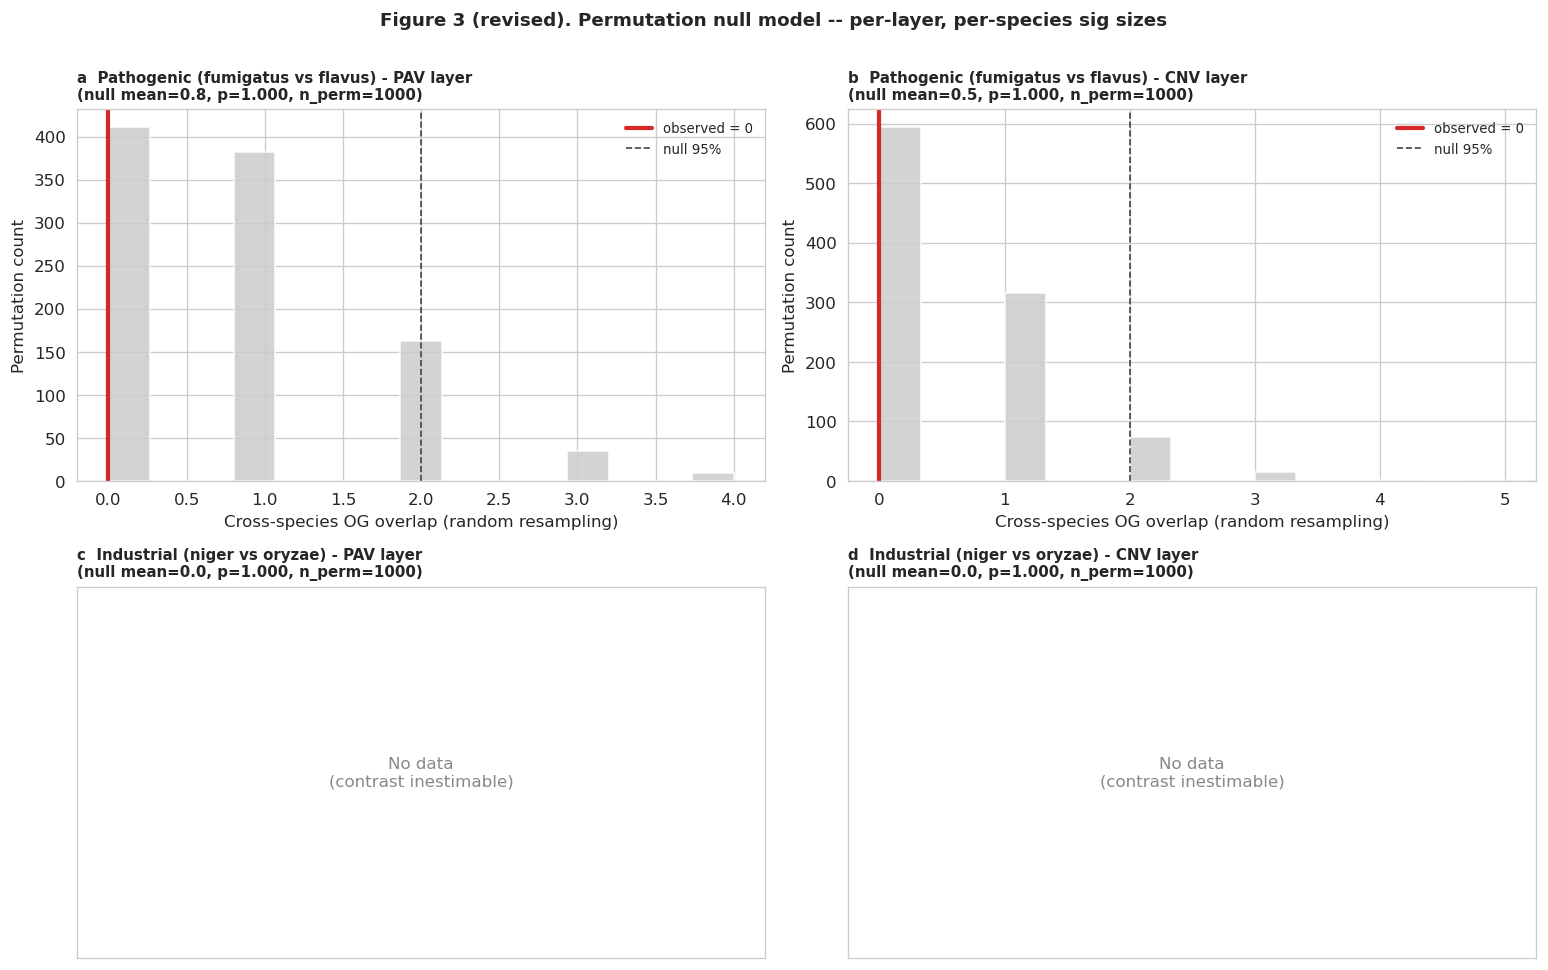

In [16]:
fig_null = fpc.plot_null_model(null_result, NB3_RESULTS, n_perms=N_PERMS)
plt.show()

---
## Section 6: Family-Level Comparisons

- CAZy families, protease families and predicted secretomes per species, from the NB1 orthogroup annotations
- Orthogroups private to excluded genomes are dropped when the annotations are loaded
- Requires NB1 annotation tables

In [17]:
# Standalone bootstrap: run this cell to use Section 6 from a fresh kernel.
import os, sys, warnings
from pathlib import Path

# --- Paths: edit these to point at your own data ---
FUNPAN_ROOT  = next(p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / 'Analysis').is_dir() and (p / 'Code').is_dir())
ANALYSIS_DIR = FUNPAN_ROOT / 'Analysis'
SPECIES_DIR  = FUNPAN_ROOT / 'Species'
GENUS        = 'Aspergillus'

SPECIES_ROOT = SPECIES_DIR / GENUS
NB0_RESULTS  = ANALYSIS_DIR / 'NB0_Results'
NB1_RESULTS  = ANALYSIS_DIR / 'NB1_Results'
NB2_RESULTS  = ANALYSIS_DIR / 'NB2_Results'
NB3_RESULTS  = ANALYSIS_DIR / 'NB3_Results'

# Combined four-species OrthoFinder run
COMBINED_OF_DIR       = SPECIES_ROOT / 'all_combined' / 'orthofinder_output' / 'Results_Apr08'
COMBINED_OG_GENECOUNT = COMBINED_OF_DIR / 'Orthogroups' / 'Orthogroups.GeneCount.tsv'
COMBINED_OG_TSV       = COMBINED_OF_DIR / 'Orthogroups' / 'Orthogroups.tsv'

# True recomputes from source and ignores every cached table
FORCE = False

sys.path.insert(0, str(ANALYSIS_DIR))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import funpan_utils as fpu
import funpan_convergence as fpc

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

SPECIES_LIST  = fpu.SPECIES_LIST
FDR_THRESHOLD = 0.1

og_consensus = fpc.load_og_consensus_filtered(SPECIES_LIST, NB1_RESULTS, SPECIES_ROOT)

fumigatus: loaded OG consensus from fumigatus_og_consensus.tsv ((10951, 23))
flavus: loaded OG consensus from flavus_og_consensus.tsv ((14463, 23))
niger: loaded OG consensus from niger_og_consensus.tsv ((12453, 23))
oryzae: loaded OG consensus from oryzae_og_consensus.tsv ((14279, 23))

Available columns (fumigatus): ['Orthogroup', 'Pangenome_Class', 'n_genomes', 'n_proteins', 'GOs', 'PFAMs', 'CAZy', 'EC', 'Description', 'COG_category', 'KEGG_ko', 'KEGG_Pathway', 'KEGG_TC', 'interpro_IPR', 'dbcan_Substrate', 'is_protease', 'protease_families', 'is_transporter', 'transporter_families', 'has_secretion_GO']
fumigatus: dropped 686 contaminant-private OGs from og_consensus
flavus: dropped 497 contaminant-private OGs from og_consensus


### 6.1 CAZy families

- Orthogroup counts per CAZy family and species, sorted by total
- Saved to `NB3_Results/cazy_family_comparison.csv`

In [18]:
cazy_pivot, _ = fpc.compare_cazy_families(og_consensus, SPECIES_LIST, NB3_RESULTS)
display(cazy_pivot.head(15))

CAZy: 278 families across 4 species


species,flavus,fumigatus,niger,oryzae,total
family,,,,,
GH3,108,83,72,101,364
GT2,86,70,72,87,315
GT0,83,59,69,80,291
GH18,77,56,66,82,281
AA3_2,70,46,70,70,256
GT1,69,50,62,68,249
GH28,54,35,46,53,188
GH76,45,38,43,46,172
AA7,50,28,42,47,167


### 6.2 Protease families

- Orthogroup counts per protease family and species, sorted by total
- Saved to `NB3_Results/protease_family_comparison.csv`

In [19]:
prot_pivot, _ = fpc.compare_protease_families(og_consensus, SPECIES_LIST, NB3_RESULTS)
display(prot_pivot.head(15))

  fumigatus: 10 protease OGs
  flavus: 11 protease OGs
  niger: 9 protease OGs
  oryzae: 9 protease OGs


species,flavus,fumigatus,niger,oryzae,total
family,,,,,
PF01432,4,0,3,4,11
PF00814,2,2,2,2,8
PF00557,0,4,0,0,4
PF00082,0,3,1,0,4
PF01650,1,0,1,1,3
PF00560,1,0,1,1,3
PF01435,1,0,1,1,3
PF00089,1,0,0,0,1
PF00246,0,1,0,0,1


### 6.3 CAZy and protease family figure

- Top CAZy and protease families per species, as two heatmaps
- Saved to `NB3_Results/family_comparison_combined.png`

Saved: /datadrive/Analysis/NB3_Results/family_comparison_combined.png


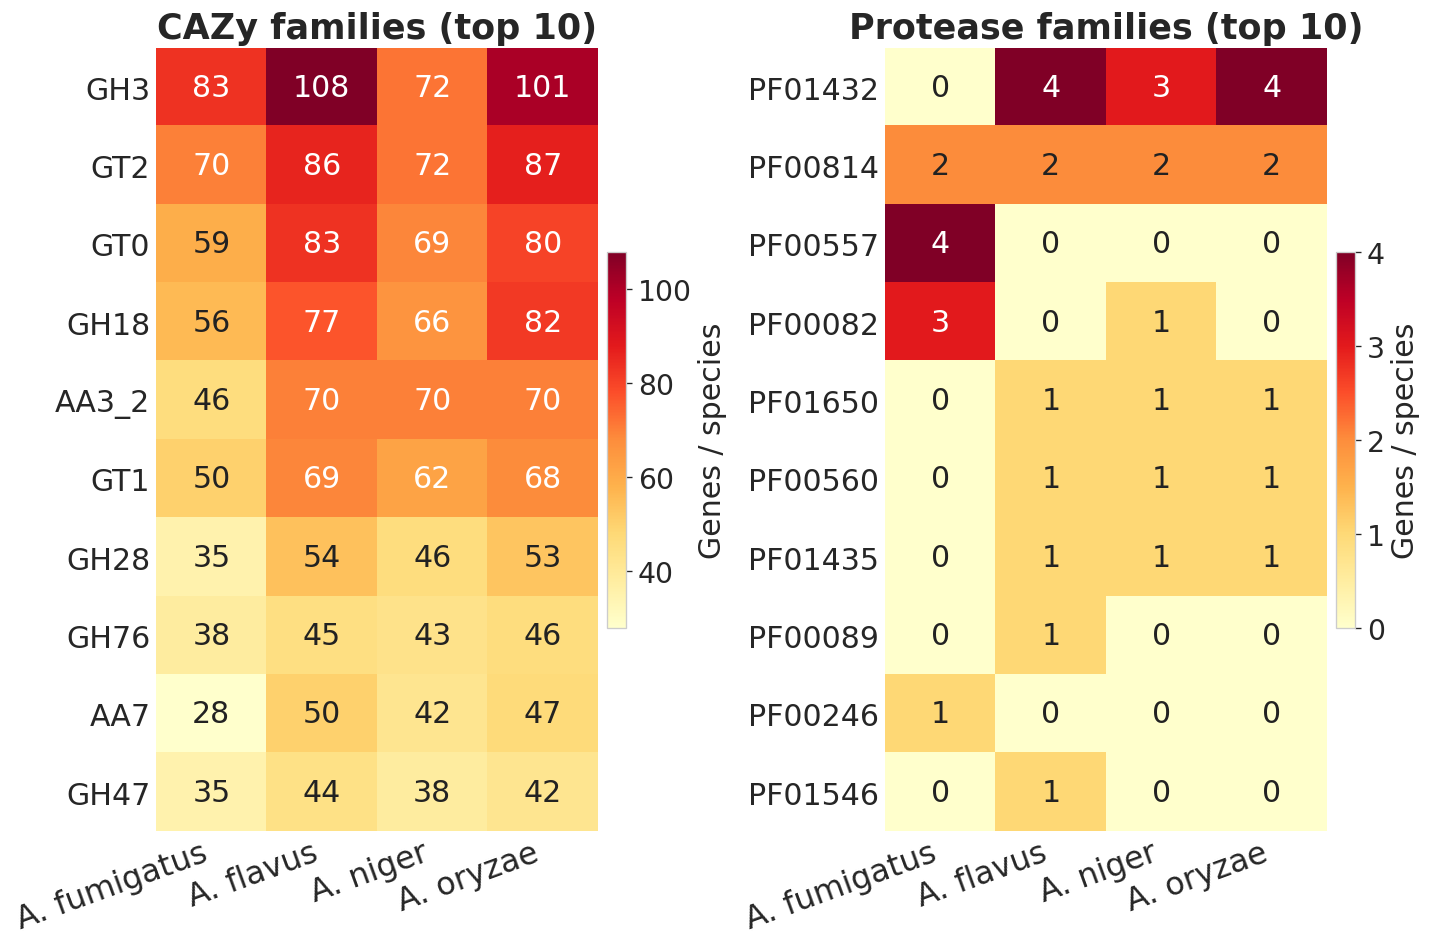

In [20]:
# --- Tweakable parameters ---
FONTSIZE    = 20
DPI         = 400
TOP_N_CAZY  = 10
TOP_N_PROT  = 10
FIG_W, FIG_H = 12.0, 8.0

fig_fam = fpc.plot_family_comparison_combined(
    NB3_RESULTS, fs_fam=FONTSIZE, dpi_fam=DPI,
    top_n_cazy=TOP_N_CAZY, top_n_prot=TOP_N_PROT,
    fig_w_fam=FIG_W, fig_h_fam=FIG_H, species=SPECIES_LIST,
)
plt.show()

### 6.4 Secretome

- Predicted secretome size per species and its split across pangenome classes
- Saved to `NB3_Results/secretome_comparison.csv`

In [21]:
secretome_df, _ = fpc.compare_secretomes(og_consensus, SPECIES_LIST, NB3_RESULTS)
display(secretome_df)

,species,n_total_OGs,n_secreted_signalp,pct_secreted_signalp,n_secretion_GO,n_secreted_in_Core,n_secreted_in_Accessory,n_secreted_in_Rare
0,fumigatus,10881,817,7.508501,6,685,102,30
1,flavus,14450,1269,8.782007,0,1035,191,43
2,niger,12453,941,7.556412,0,778,147,16
3,oryzae,14279,1194,8.361930,1,1001,169,24


### 6.5 Secretome figure

- Secretome size per species, split by pangenome class
- Saved to `NB3_Results/secretome_combined.png`

Saved: /datadrive/Analysis/NB3_Results/secretome_combined.png


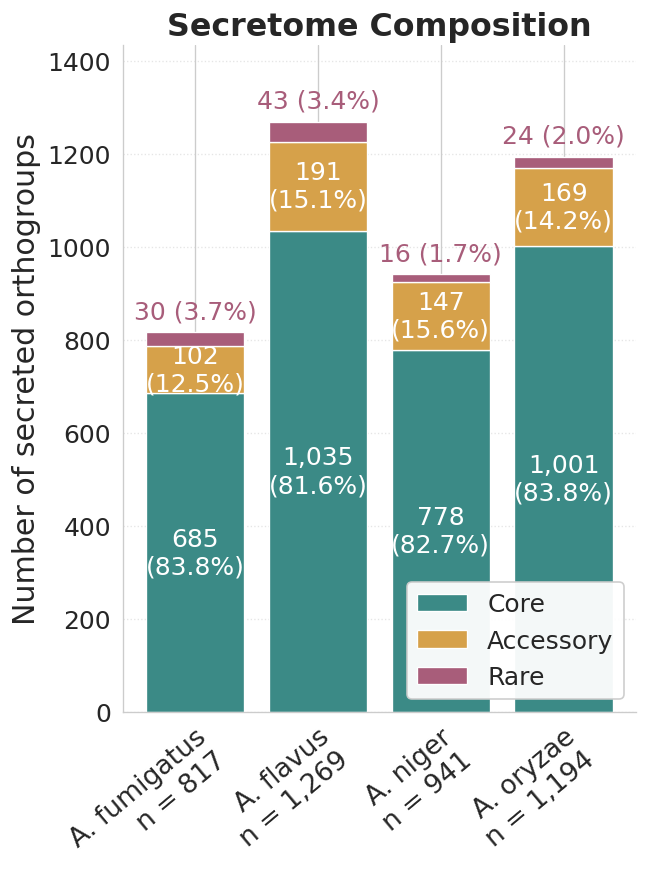

In [22]:
# --- Tweakable parameters ---
FONTSIZE = 18
DPI      = 400
FIG_W, FIG_H = 5.5, 7.5
CORE_C, ACC_C, RARE_C = '#3b8a86', '#d6a14a', '#a85d7a'

fig_sec_combined = fpc.plot_secretome_stacked(
    NB3_RESULTS, fs_sec=FONTSIZE, dpi_sec=DPI,
    fig_w_sec=FIG_W, fig_h_sec=FIG_H,
    core_c=CORE_C, acc_c=ACC_C, rare_c=RARE_C, species=SPECIES_LIST,
)
plt.show()

---
## Section 7: Functional Convergence

- Jaccard overlap of each species pair's enriched annotation terms, per layer and contrast, against a permutation null
- Saved to `NB3_Results/functional_convergence_results.csv`
- Requires Section 6 and the NB2 enrichment tables

In [23]:
# Standalone bootstrap: run this cell to use Section 7 from a fresh kernel.
import os, sys, warnings
from pathlib import Path

# --- Paths: edit these to point at your own data ---
FUNPAN_ROOT  = next(p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / 'Analysis').is_dir() and (p / 'Code').is_dir())
ANALYSIS_DIR = FUNPAN_ROOT / 'Analysis'
SPECIES_DIR  = FUNPAN_ROOT / 'Species'
GENUS        = 'Aspergillus'

SPECIES_ROOT = SPECIES_DIR / GENUS
NB0_RESULTS  = ANALYSIS_DIR / 'NB0_Results'
NB1_RESULTS  = ANALYSIS_DIR / 'NB1_Results'
NB2_RESULTS  = ANALYSIS_DIR / 'NB2_Results'
NB3_RESULTS  = ANALYSIS_DIR / 'NB3_Results'

# Combined four-species OrthoFinder run
COMBINED_OF_DIR       = SPECIES_ROOT / 'all_combined' / 'orthofinder_output' / 'Results_Apr08'
COMBINED_OG_GENECOUNT = COMBINED_OF_DIR / 'Orthogroups' / 'Orthogroups.GeneCount.tsv'
COMBINED_OG_TSV       = COMBINED_OF_DIR / 'Orthogroups' / 'Orthogroups.tsv'

# True recomputes from source and ignores every cached table
FORCE = False

sys.path.insert(0, str(ANALYSIS_DIR))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import funpan_utils as fpu
import funpan_convergence as fpc

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

SPECIES_LIST  = fpu.SPECIES_LIST
FDR_THRESHOLD = 0.1

og_consensus = fpc.load_og_consensus_filtered(SPECIES_LIST, NB1_RESULTS, SPECIES_ROOT)

fumigatus: loaded OG consensus from fumigatus_og_consensus.tsv ((10951, 23))
flavus: loaded OG consensus from flavus_og_consensus.tsv ((14463, 23))
niger: loaded OG consensus from niger_og_consensus.tsv ((12453, 23))
oryzae: loaded OG consensus from oryzae_og_consensus.tsv ((14279, 23))

Available columns (fumigatus): ['Orthogroup', 'Pangenome_Class', 'n_genomes', 'n_proteins', 'GOs', 'PFAMs', 'CAZy', 'EC', 'Description', 'COG_category', 'KEGG_ko', 'KEGG_Pathway', 'KEGG_TC', 'interpro_IPR', 'dbcan_Substrate', 'is_protease', 'protease_families', 'is_transporter', 'transporter_families', 'has_secretion_GO']
fumigatus: dropped 686 contaminant-private OGs from og_consensus
flavus: dropped 497 contaminant-private OGs from og_consensus


In [24]:
# --- Tweakable parameters ---
FUNC_CONV_N_PERM  = 1000
FUNCTIONAL_LAYERS = ['COG_category', 'PFAMs', 'CAZy', 'KEGG_ko', 'KEGG_Pathway',
                     'KEGG_TC', 'GOs', 'interpro_IPR', 'EC', 'dbcan_Substrate']

func_conv_df, func_conv_raw = fpc.run_functional_convergence(
    og_consensus, NB2_RESULTS, NB3_RESULTS,
    func_conv_n_perm=FUNC_CONV_N_PERM, functional_layers=FUNCTIONAL_LAYERS,
)


  fumigatus vs flavus | human_pathogenic_vs_rest: 94 vs 63 sig OGs

  fumigatus vs flavus | environmental_vs_rest: 94 vs 29 sig OGs

  niger vs oryzae | industrial_trait_vs_rest: 2 vs 0 sig OGs
    -> NOT TESTABLE (one species has 0 sig OGs)

  niger vs oryzae | environmental_vs_rest: 114 vs 0 sig OGs
    -> NOT TESTABLE (one species has 0 sig OGs)

  flavus vs niger | environmental_vs_rest: 29 vs 114 sig OGs

  Completed 3 pair x contrast in 24s

  Saved: NB3_Results/functional_convergence_results.csv

  Significant functional convergence (q<0.05 per pair/contrast): 0

  Top 5 trends by p_value (none survive FDR):
      sp1    sp2                 contrast        layer  n_shared_terms  observed_jaccard  null_mean_jaccard  p_value
fumigatus flavus human_pathogenic_vs_rest          GOs               1          0.071429           0.009702    0.027
fumigatus flavus    environmental_vs_rest         CAZy               1          0.142857           0.035805    0.051
fumigatus flavus human_pa

### 7.1 Observed against null Jaccard

- One panel per species pair and contrast
- Saved to `NB3_Results/functional_convergence.png`

Saved: NB3_Results/functional_convergence.png


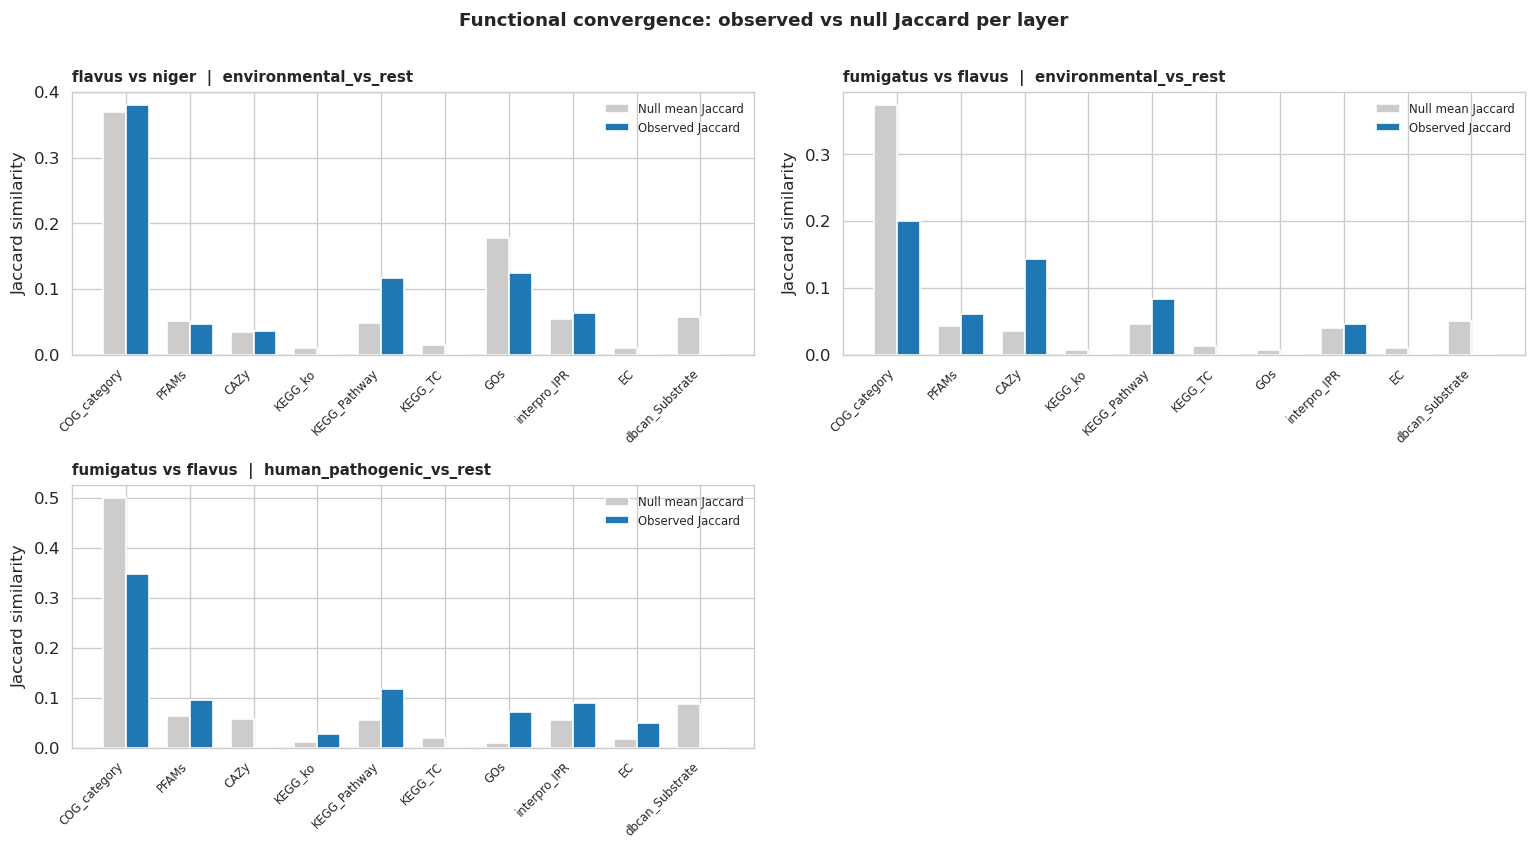

In [25]:
fig_jac = fpc.plot_functional_convergence_jaccard(func_conv_df, NB3_RESULTS)
plt.show()

### 7.2 Functional convergence per layer

- Observed against null Jaccard per annotation layer for one species pair and contrast, with the q-value per layer
- Saved to `NB3_Results/functional_convergence_combined.png`

fumigatus x flavus | human_pathogenic_vs_rest: 10 annotation layers
Saved: /datadrive/Analysis/NB3_Results/functional_convergence_combined.png


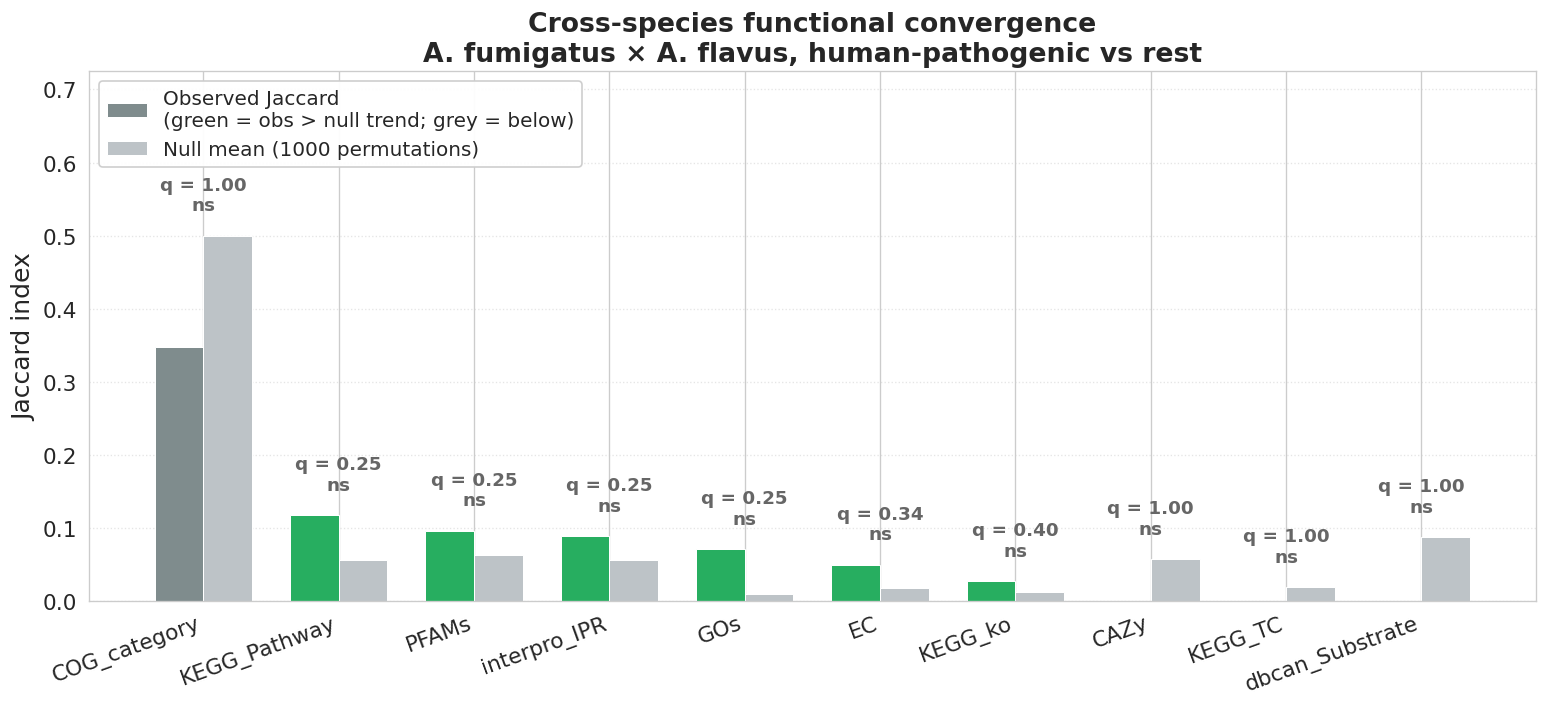

In [26]:
# --- Tweakable parameters ---
FONTSIZE = 15
DPI      = 400
FIG_W, FIG_H = 13.0, 6.0
Q_THRESHOLD = 0.05
SP1, SP2, CONTRAST = 'fumigatus', 'flavus', 'human_pathogenic_vs_rest'

fig_fc = fpc.plot_functional_null_result(
    NB3_RESULTS, fs_fc=FONTSIZE, dpi_fc=DPI,
    fig_w_fc=FIG_W, fig_h_fc=FIG_H, q_threshold_fc=Q_THRESHOLD,
    sp1_fc=SP1, sp2_fc=SP2, contrast_fc=CONTRAST,
)
plt.show()

---
## Section 8: Summary

- Directional concordance per layer
- Every output file with its full path under `NB3_Results/`

In [27]:
# Standalone bootstrap: run this cell to use Section 8 from a fresh kernel.
import os, sys, warnings
from pathlib import Path

# --- Paths: edit these to point at your own data ---
FUNPAN_ROOT  = next(p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / 'Analysis').is_dir() and (p / 'Code').is_dir())
ANALYSIS_DIR = FUNPAN_ROOT / 'Analysis'
SPECIES_DIR  = FUNPAN_ROOT / 'Species'
GENUS        = 'Aspergillus'

SPECIES_ROOT = SPECIES_DIR / GENUS
NB0_RESULTS  = ANALYSIS_DIR / 'NB0_Results'
NB1_RESULTS  = ANALYSIS_DIR / 'NB1_Results'
NB2_RESULTS  = ANALYSIS_DIR / 'NB2_Results'
NB3_RESULTS  = ANALYSIS_DIR / 'NB3_Results'

# Combined four-species OrthoFinder run
COMBINED_OF_DIR       = SPECIES_ROOT / 'all_combined' / 'orthofinder_output' / 'Results_Apr08'
COMBINED_OG_GENECOUNT = COMBINED_OF_DIR / 'Orthogroups' / 'Orthogroups.GeneCount.tsv'
COMBINED_OG_TSV       = COMBINED_OF_DIR / 'Orthogroups' / 'Orthogroups.tsv'

# True recomputes from source and ignores every cached table
FORCE = False

sys.path.insert(0, str(ANALYSIS_DIR))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import funpan_utils as fpu
import funpan_convergence as fpc

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

SPECIES_LIST  = fpu.SPECIES_LIST
FDR_THRESHOLD = 0.1


In [28]:
summary_counts, summary_files = fpc.print_nb3_summary(SPECIES_LIST, NB3_RESULTS)
display(summary_counts)

NB3 Cross-Species Convergence complete.
All outputs saved to: /datadrive/Analysis/NB3_Results
    /datadrive/Analysis/NB3_Results/method3_projection_accounting.csv
    /datadrive/Analysis/NB3_Results/method3_directional_concordance.csv
    /datadrive/Analysis/NB3_Results/method3_merge_rule_sensitivity.csv
    /datadrive/Analysis/NB3_Results/convergence/pathogenic_method3_pav_convergence.csv
    /datadrive/Analysis/NB3_Results/convergence/pathogenic_method3_cnv_convergence.csv
    /datadrive/Analysis/NB3_Results/cross_species_gcf_convergence.csv
    /datadrive/Analysis/NB3_Results/permutation_null_model.csv
    /datadrive/Analysis/NB3_Results/convergence_null_model.png
    /datadrive/Analysis/NB3_Results/cazy_family_comparison.csv
    /datadrive/Analysis/NB3_Results/protease_family_comparison.csv
    /datadrive/Analysis/NB3_Results/secretome_comparison.csv
    /datadrive/Analysis/NB3_Results/functional_convergence_results.csv
    /datadrive/Analysis/NB3_Results/functional_convergence.pn

,n_shared_tested,n_concordant,n_discordant,pct_concordant,sign_test_p,spearman_rho,n_sig_both
layer,,,,,,,
PAV,448,221,227,49.3,0.813288,-0.023128,0
CNV,448,220,228,49.1,0.740898,-0.019663,0
